In [ ]:
!pip install mne wfdb

In [ ]:
!wget -r -N -c -np https://physionet.org/files/eegmat/1.0.0/

--2026-02-13 18:22:56--  https://physionet.org/files/eegmat/1.0.0/
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘physionet.org/files/eegmat/1.0.0/index.html’

physionet.org/files     [ <=>                ]   9.11K  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2026-02-13 18:22:57 (194 MB/s) - ‘physionet.org/files/eegmat/1.0.0/index.html’ saved [9326]

Loading robots.txt; please ignore errors.
--2026-02-13 18:22:57--  https://physionet.org/robots.txt
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 22 [text/plain]
Saving to: ‘physionet.org/robots.txt’

physionet.org/robot 100%[===================>]      22  --.-KB/s    in 0s      

2026-02-13 18:22:57 (5.13 MB/s) - ‘physionet.org/robots.txt’ saved [22/22]

--2026-02-13 18:22:

In [ ]:
import mne

file_path = "physionet.org/files/eegmat/1.0.0/Subject01_1.edf"
raw = mne.io.read_raw_edf(file_path, preload=True)

raw

Extracting EDF parameters from physionet.org/files/eegmat/1.0.0/Subject01_1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 90999  =      0.000 ...   181.998 secs...


<RawEDF | Subject01_1.edf, 21 x 91000 (182.0 s), ~14.6 MiB, data loaded>

Using matplotlib as 2D backend.


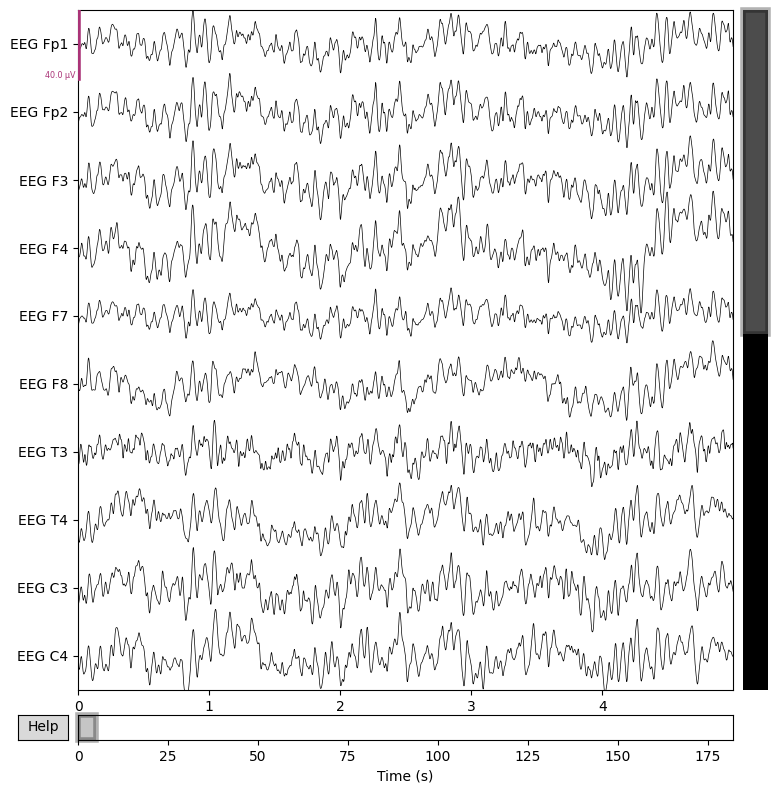

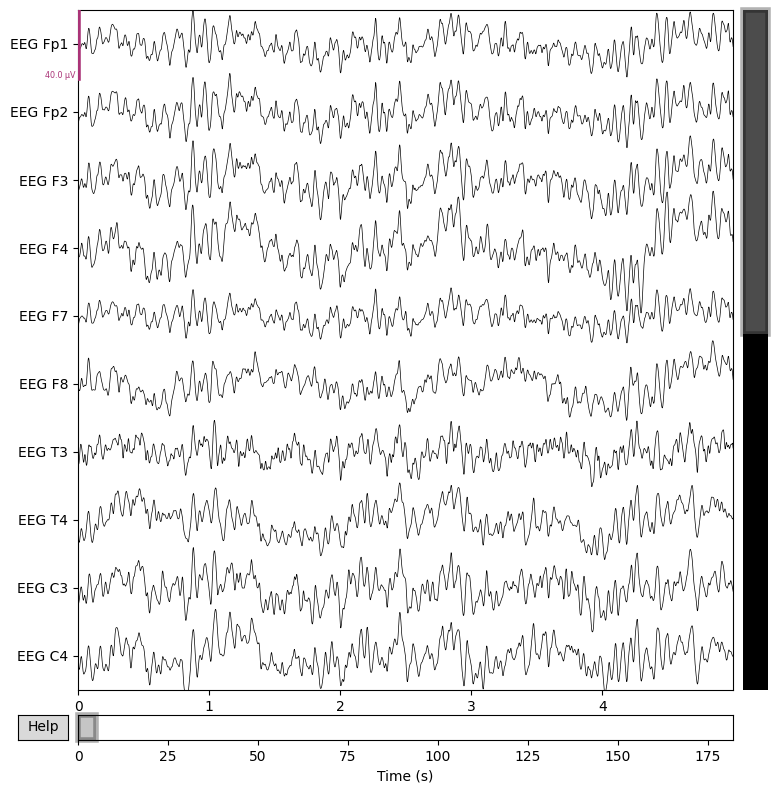

In [ ]:
raw.plot(n_channels=10, duration=5)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (3.302 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edg

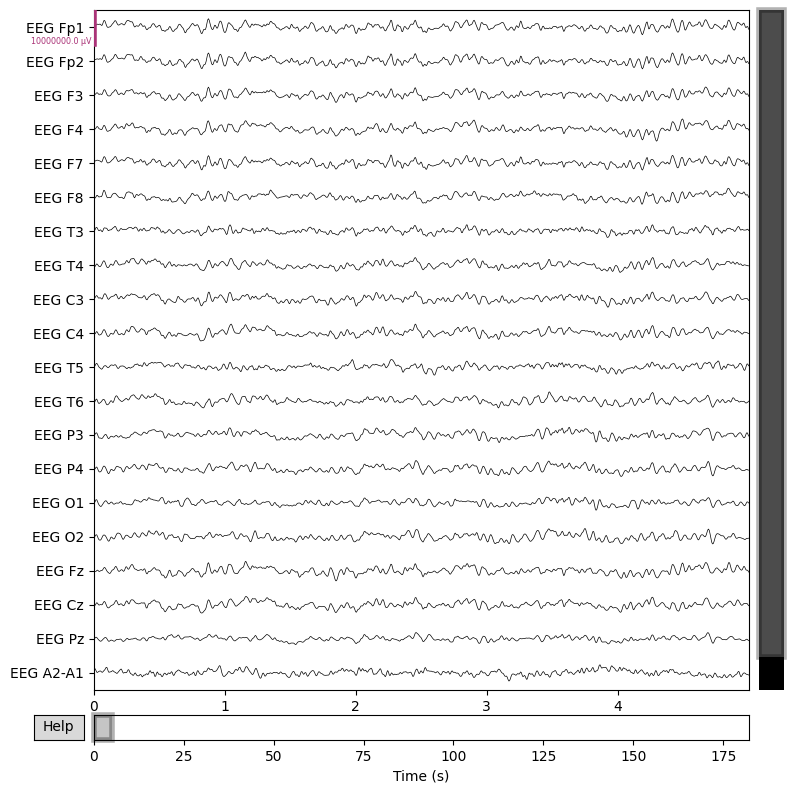

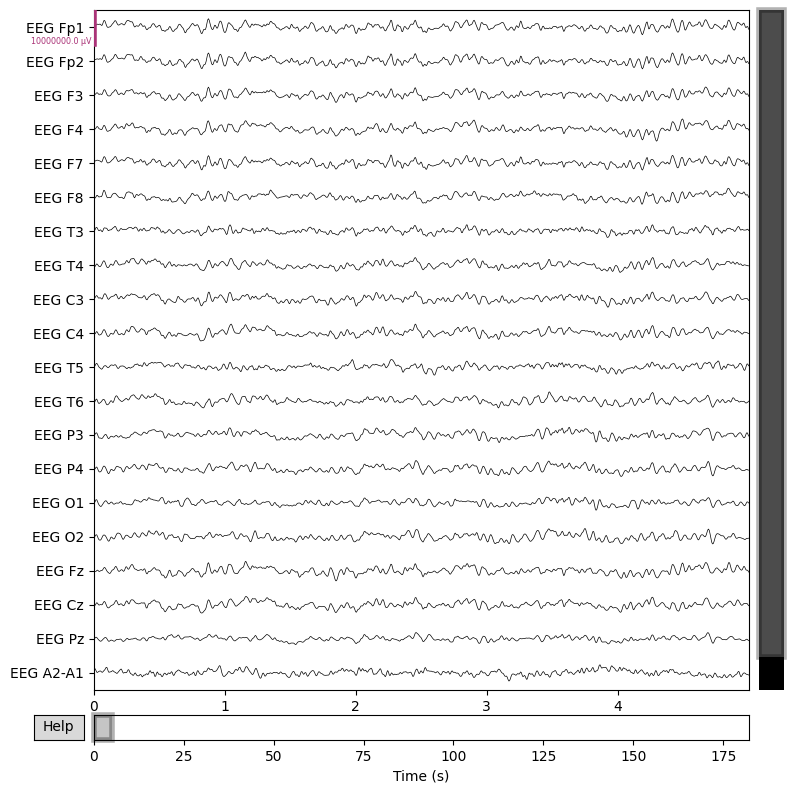

In [ ]:

raw_filtered = raw.copy().filter(l_freq=1, h_freq=45)


raw_filtered = raw_filtered.notch_filter(freqs=50)
raw_filtered._data = (raw_filtered._data - raw_filtered._data.mean(axis=1, keepdims=True)) / raw_filtered._data.std(axis=1, keepdims=True)

print("Bandpass + Notch filtering done")

raw_filtered.plot(scalings=dict(eeg=5), duration=5)

In [ ]:
import numpy as np

# Get filtered data
data = raw_filtered.get_data()

sfreq = raw_filtered.info['sfreq']  # sampling frequency
window_size = int(2 * sfreq)  # 2-second window

segments = []

for start in range(0, data.shape[1] - window_size, window_size):
    segment = data[:, start:start+window_size]
    segments.append(segment)

segments = np.array(segments)

print("Segments shape:", segments.shape)

Segments shape: (90, 21, 1000)


In [ ]:
labels = np.zeros(len(segments))  # 0 = rest

print("Labels shape:", labels.shape)

Labels shape: (90,)


In [ ]:
import mne

raw2 = mne.io.read_raw_edf(
    "physionet.org/files/eegmat/1.0.0/Subject01_2.edf",
    preload=True
)

raw2_filtered = raw2.filter(1., 45.)
raw2_filtered = raw2_filtered.notch_filter(freqs=50)
raw2_filtered._data = (raw2_filtered._data - raw2_filtered._data.mean(axis=1, keepdims=True)) / raw2_filtered._data.std(axis=1, keepdims=True)

Extracting EDF parameters from physionet.org/files/eegmat/1.0.0/Subject01_2.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 30999  =      0.000 ...    61.998 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (3.302 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) m

In [ ]:
data2 = raw2_filtered.get_data()

sfreq2 = raw2_filtered.info['sfreq']
window_size2 = int(2 * sfreq2)

segments2 = []

for start in range(0, data2.shape[1] - window_size2, window_size2):
    segment = data2[:, start:start+window_size2]
    segments2.append(segment)

segments2 = np.array(segments2)

print("Arithmetic segments shape:", segments2.shape)

Arithmetic segments shape: (30, 21, 1000)


In [ ]:
labels2 = np.ones(len(segments2))  # 1 = arithmetic

print("Arithmetic labels shape:", labels2.shape)

Arithmetic labels shape: (30,)


In [ ]:
X = np.concatenate((segments, segments2), axis=0)
y = np.concatenate((labels, labels2), axis=0)

print("Final data shape:", X.shape)
print("Final labels shape:", y.shape)

Final data shape: (120, 21, 1000)
Final labels shape: (120,)
